# ASSETS: AStr211 Synthetic Echelle Training Spectrograph

    Created: Ethan Bull, June 2024
    Edited: Ethan Bull & Dr. C. Clare Worley, August 2024

In this notebook you will learn how to reduce data from an echelle spectrograph. The data you will use is a synthesised image containing data from a star that shares parameters from μ Ara.

In [2]:
# Import the python modules you will need. You can use others, but the entire lab can be done with these.
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from astropy.io import fits
import scipy as sp
import glob
import os
from scipy.optimize import minimize

%matplotlib inline

# Task 1: Opening and inspecting the data
There are 17 fits files on MacDiarmid in the 'Spec_Reduction_Lab' folder associated with this notebook, representing data from four different exposure types:
- Raw Stellar
- Thorium-Argon (ThAr, thorium) lamp
- White
- Dark

These files contain data in the form that an echelle spectrograph would produce as covered in lectures. We will use these files to generate the spectrum of a star (i.e. flux versus wavelength).

Follow these steps to open and display the data from each file:
1. Separate each file type into lists using code from a previous Lab.
2. Extract the data from the primary extension.
3. Plot the data. Don't forget titles.

Summarise the types of images and any errors you notice in your data reduction log.


In [3]:
# bringing in our data from macdiarmid

folder = '//macdiarmid/ASTR211/2024_Lab_Files/Spec_Reduction_Lab/' # This is the direct folder with the files

# Goes through and finds each file in a designated folder

files = [folder + file for file in os.listdir(folder) if '.fit' in file]

# Goes through and finds each file with a specific pattern in the folder, alternate method (puts in a list)
# This method is architecture dependent (e.g. the order for a MacOs M3 will be different to a Windows HP)
raws, thars, whites, darks, = [],[],[],[]

for file in files:
    hdul = fits.open(file)
    img_type = hdul[0].header['EXPTYPE']
    hdul.close()
    if img_type == "White Light":
        whites.append(file)
    elif img_type == "Thorium":
        thars.append(file)
    elif img_type == "Stellar":
        raws.append(file)
    else:
        darks.append(file)
print(f"Darks: {len(darks)}")
print(f"ThArs: {len(thars)}")
print(f"Whites: {len(whites)}")
print(f"Raws: {len(raws)}")

Darks: 5
ThArs: 1
Whites: 10
Raws: 1


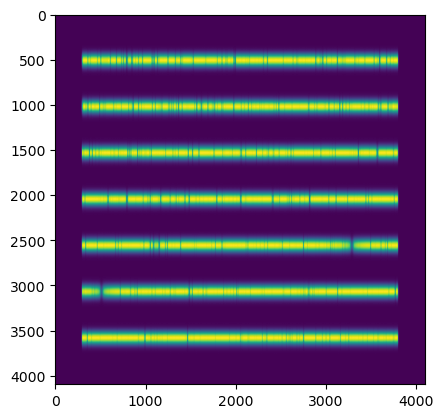

<Figure size 640x480 with 0 Axes>

In [9]:
# lets inspect each raw image
for file in raws:
    hdul = fits.open(file)
    raw = hdul[0].data
    hdul.close()
    plt.imshow(raw)
    plt.figure()
#raws and darks are good

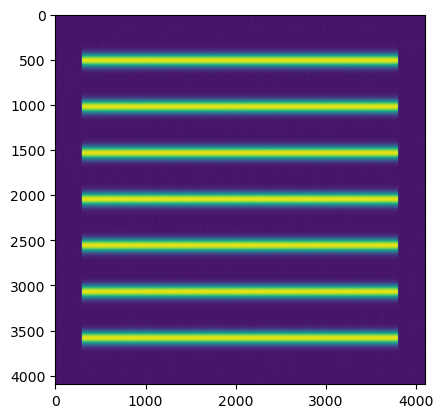

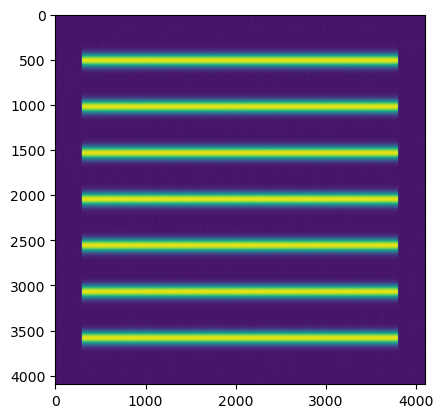

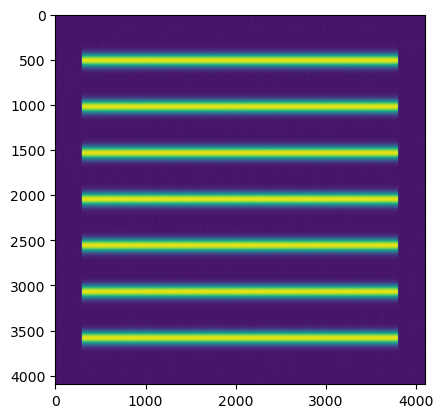

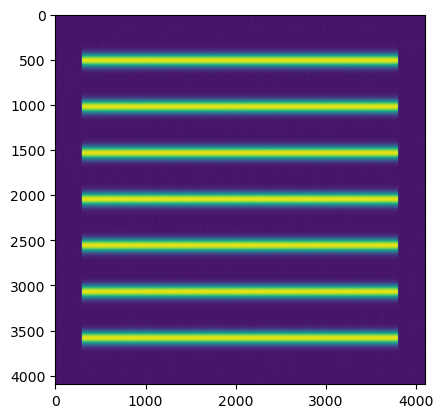

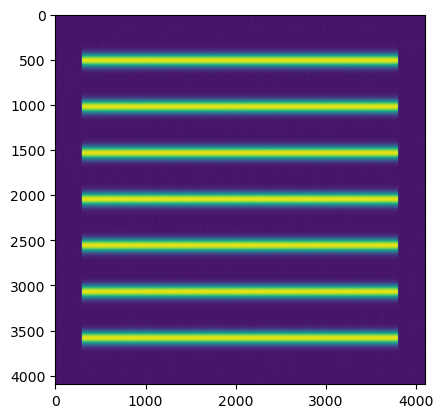

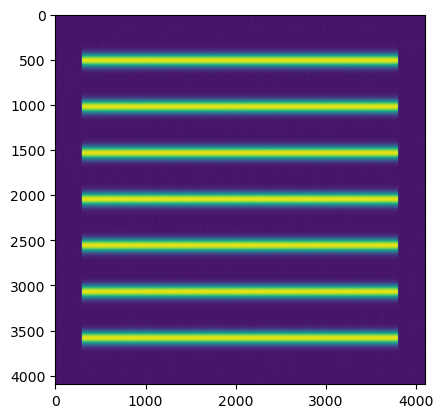

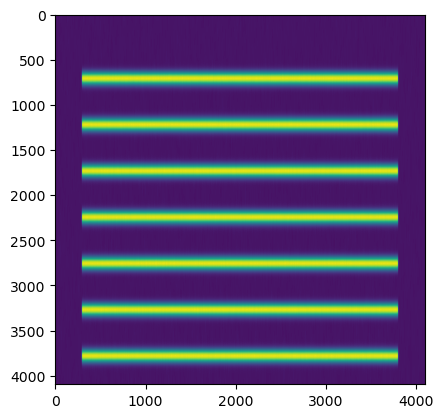

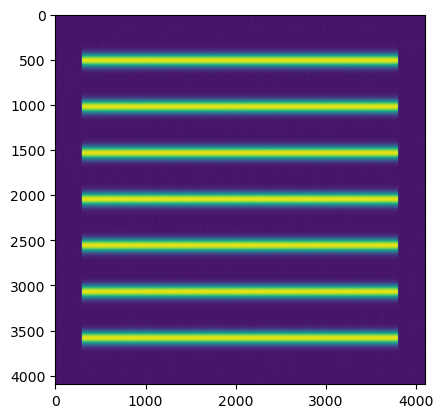

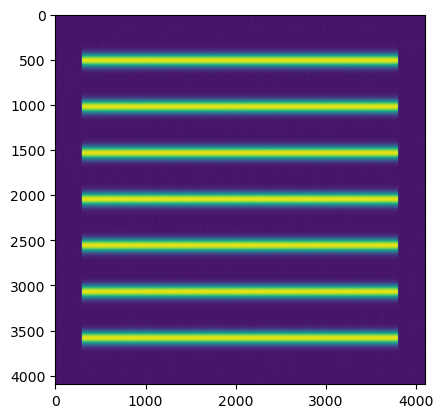

<Figure size 640x480 with 0 Axes>

In [10]:
# lets inspect each image
#one of our whites is bad so we'll pop it
whites.pop(4)
for file in whites:
    hdul = fits.open(file)
    raw = hdul[0].data
    hdul.close()
    plt.imshow(raw)
    plt.figure()

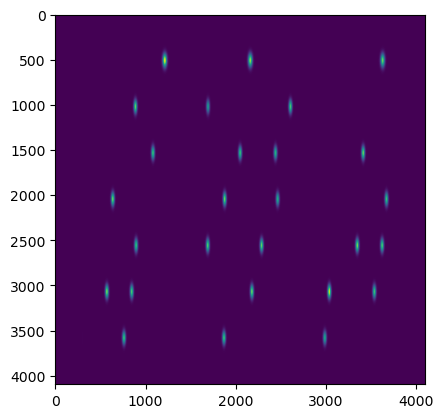

<Figure size 640x480 with 0 Axes>

In [11]:
# lets check our thar
for file in thars:
    hdul = fits.open(file)
    raw = hdul[0].data
    hdul.close()
    plt.imshow(raw)
    plt.figure()

You can clearly see how the 'raw' spectrum has been split up into multiple parallel 'orders'. Now it's time to start reducing the data. 

# Task 2: Creating calibration files

As we did last week, we need to create some master calibration files. We need a master white for order-tracing and we need a master dark for reducing the raw image.

For this process we will NOT use the whites in the reduction. So we do NOT need a master dark for the whites.

Follow these steps to create calibration images
1. Use your list of darks and code from previous lab to create a master dark
2. Repeat step 1 with your list of whites taking a 'median'
3. Repeat step 2 taking a 'mean'
4. Plot your three master calibration images

Think about your master images compared to the individual images.

What's the difference between the two master whites? Why is this? 

Discuss with a tutor and record in your log.


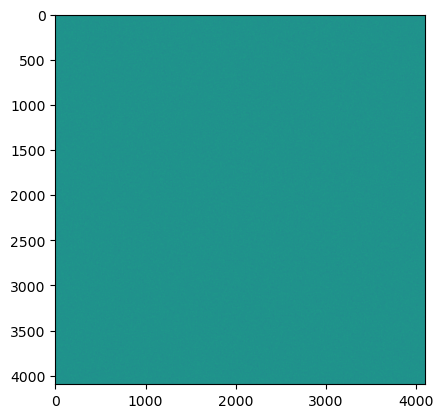

In [13]:
# first lets check our exposure times for the darks
# for dark in darks:
#     hdul = fits.open(dark)
#     header = hdul[0].header
#     hdul.close()
#     print(header["EXPTIME"])

darks_data = []
for dark_file in darks:
    hdul = fits.open(dark_file)
    darks_data.append(hdul[0].data) # Append the data to the list
    hdul.close()

master_dark = np.median(darks_data, axis=0) # Median combine the darks
plt.imshow(master_dark)
# master dark looks good

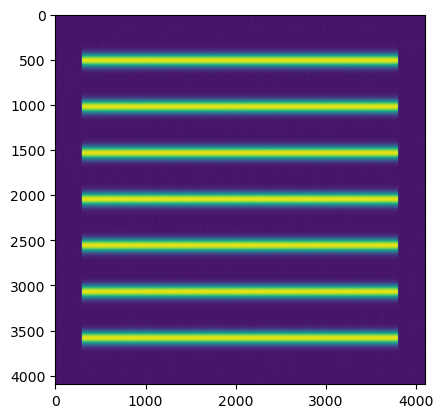

In [20]:
# now for our master lights
whites_data = []
for white in whites:
    hdul = fits.open(white)
    whites_data.append(hdul[0].data) # Append the data to the list
    hdul.close()
master_white_median = np.median(whites_data, axis=0) # Median combine the lights
master_white_mean = np.mean(whites_data, axis=0) # mean combine the lights
plt.imshow(master_white_median)

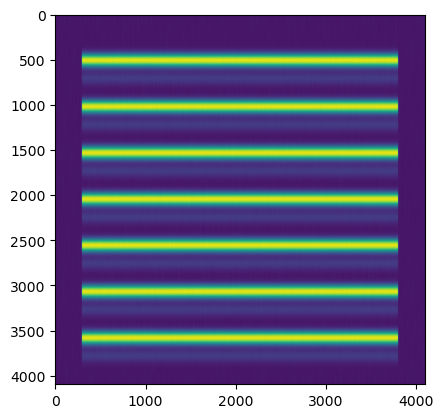

In [21]:
plt.imshow(master_white_mean)


# Task 3: Reducing and order tracing

First we will do a minimal reduction of the raw image by subtracting the master dark from the raw image. Then we will inspect the orders in the 'medianed' master white from earlier and try to trace them.

Follow these steps:

1. Subtract the master dark from the raw image to get the reduced raw image.
2. Extract a column slice from the medianed master white.
3. Plot the column slice to visually confirm where the orders are located in the reduced raw image.
4. Below is an example of using scipy's signal.find_peaks. This function will return index values at the location of the peaks in the column slice.
5. Overplot vertical lines using plt.axvline on your column slice plot using the indices returned by find_peaks. Do the set of lines make sense?
6. Adjust the height parameter in find_peaks to only detect the orders in the master white. What value did you use? Discuss with tutor and record in log.
7. Replot your master white.
8. Overplot horizontal lines using plt.axhline on your master white.
9. Plot your reduced raw image.
10. Overplot horizontal lines using plt.axhline on your reduced raw image.

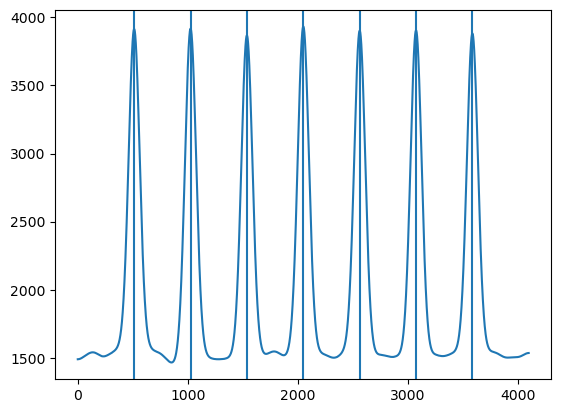

In [32]:
hdul = fits.open(raws[0])
raw = hdul[0].data
hdul.close()

min_reduced_raw = raw - master_dark

med_white_col = master_white_median[:,2000]
# plt.imshow(min_reduced_raw)
plt.figure()
plt.plot(med_white_col)
order_pixel_values, order_info = sp.signal.find_peaks(med_white_col, height = 2000)

for value in order_pixel_values:
    plt.axvline(value)



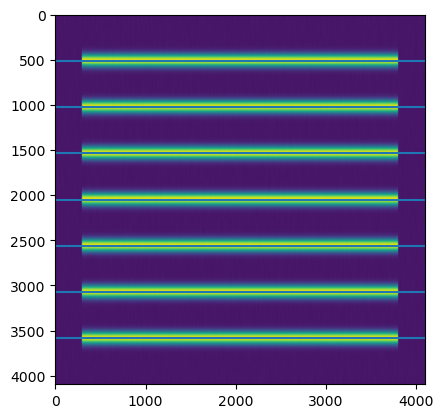

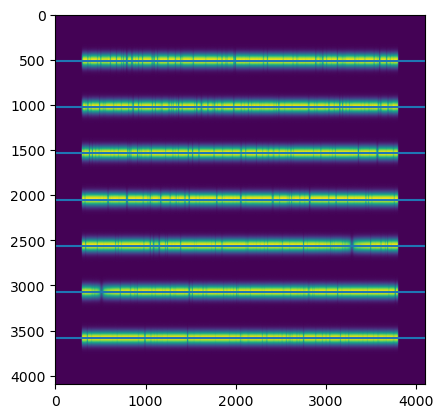

In [35]:
plt.imshow(master_white_median)
for value in order_pixel_values:
    plt.axhline(value)
plt.figure()
plt.imshow(min_reduced_raw)
for value in order_pixel_values:
    plt.axhline(value)

You have just traced your orders! 

Normally orders are not straight lines and you would have to fit a polynomial to your orders to do the tracing.

# Task 4: Extracting one order

We will focus on extracting and wavelength-calibrating one order.

Scipy's 'find_peaks' function should have returned a list of seven indices corresponding to the seven orders in the reduced raw image. You will pick one of these orders and extract the flux in that order, first from the reduced raw image and then the thorium image.

Follow these steps:

1. Pick one of the orders that contain the hydrogen alpha (H-alpha) line, which is the thickest absorption line you can see. The H-alpha line is in both orders 5 and 6. Why is it in multiple orders? Discuss with a tutor and record in your log 
2. Your order number corresponds to an index that you can use to retrieve the row location of the order in the image. Remember that python indexing starts at 0, but we count the orders from 1. Extract the row location of your order.
3. Extract the flux of your order from your reduced raw image using a row slice.
4. Plot your order as flux versus pixel.
5. Repeat steps 3 and 4 for the thorium image.

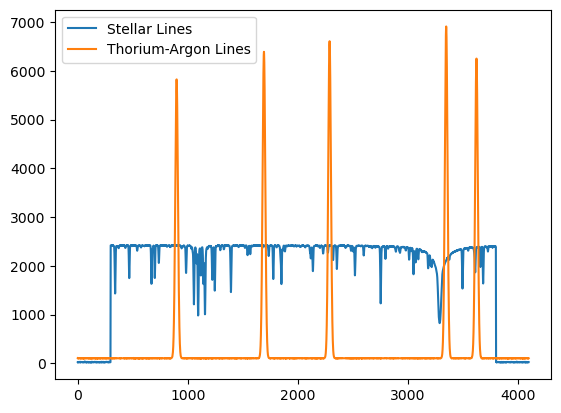

In [39]:
order = min_reduced_raw[order_pixel_values[4]]
plt.plot(order, label="Stellar Lines")

hdul = fits.open(thars[0])
thar = hdul[0].data
hdul.close()
thar_order = thar[order_pixel_values[4]]
plt.plot(thar_order, label="Thorium-Argon Lines")
plt.legend()

You now have the flux for your order from your reduced raw image and from your thorium image in pixel-space.

# Task 5: Navigating a ThAr Atlas


The thorium image is the map between pixel-space and wavelength-space. This is because when a Thorium-Argon lamp is heated, it emits light at precise, well-known wavelengths that are well-distributed throughout the spectrum. 

A Thorium-Argon (ThAr) Atlas is used to impose wavelengths on the orders in a thorium image. 

The Atlas we will use is the ThAr_linelist.txt found in the data folder. This linelist tells you which ThAr lines are in which orders and their corresponding wavelengths.

Follow these steps:

1. Print the ThAr linelist to inspect its column names and contents. 
2. Using your order number, extract the list of ThAr lines in your order. 

There are a variety of ways to do this:
- Pandas masking: You can generate a list of True or False values to use as a mask to reduce the pandas dataframe to your required lines. Ask a tutor if you would like to learn how to do this.
- List comprehension or loops: Loop over the rows of the dataframe either with a For loop, or using comprehension, to test each row to see if it meets your condition i.e. order == order number or order2 == order number.
- Manual: Copy and paste the wavelengths for your order into a vector. This will be tricky if processing multiple orders.

NOTE: For pixel to wavelength mapping, this list MUST be in wavelength order.

Discuss your process with a tutor and record it in your log.

In [53]:
linelist = np.loadtxt("//macdiarmid\ASTR211/2024_Lab_Files/Spec_Reduction_Lab/ThAr_linelist.txt", skiprows=1)

lines = []
for line in linelist:
    if int(line[2]) == 5 or int(line[3]) == 5:
        lines.append(line)
print(len(lines))
print(lines)

5
[array([648.89268084,   0.93778867,   4.        ,   5.        ]), array([657.31371493,   1.00699654,   5.        ,   6.        ]), array([651.34494354,   1.03031866,   5.        ,  -1.        ]), array([653.189382  ,   1.06573184,   5.        ,  -1.        ]), array([656.46388445,   1.11532869,   5.        ,   6.        ])]


# Task 6: Mapping pixels to wavelengths I

Now, you need to convert from pixel-space to wavelength-space. 

Follow these steps:
1. Use scipy's signal.find_peaks again to extract the pixel positions of the thorium lines in your order. Remember to adjust the height (and distance) arguments so you extract the pixel values for all the lines. 
2. Plot the thorium order again and overplot vertical lines at the pixel positions of each ThAr line.

Do you have the same number of pixel values as you do thorium lines in your order? If not, discuss with tutor.


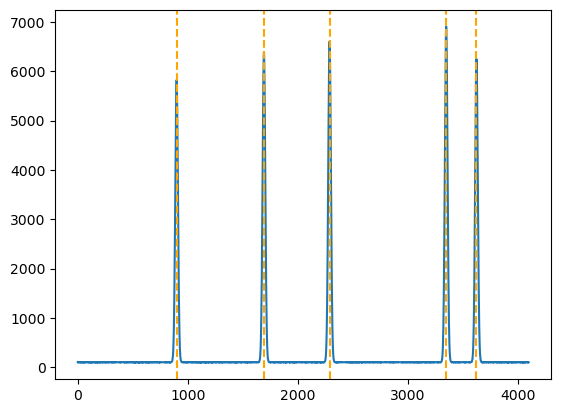

In [49]:
thar_lines, info = sp.signal.find_peaks(thar_order, height = 2000)
plt.plot(thar_order)

for line in thar_lines:
    plt.axvline(line, color="orange", linestyle='--')

# Task 7: Mapping pixels to wavelengths II

We will now inspect the pixels to wavelengths relationship using our pixel positions and corresponding ThAr wavelengths. We will fit a polynomial to this relationship to map pixels to wavelengths.

Follow these steps:

1. Plot the pixel-wavelength space that you have just found i.e. pixels on the x-axis and wavelength on y-axis. What does the relation look like? Discuss with tutor and record in log.
2. Use np.polyfit with pixel positions as your independant variable and their corresponding ThAr wavelengths as the dependent variable to determine the coefficients for your line equation.
3. Make a vector of pixel values for your order. HINT: The indices of your flux vector is your pixel vector. 
4. Pass your pixel vector and coefficients through np.polyval to return the wavelength vector for your order.
5. Plot your order as flux versus wavelength. Don't forget to add labels.

Save your plot as a PNG, and upload this as your best effort reduced spectrum to LEARN.

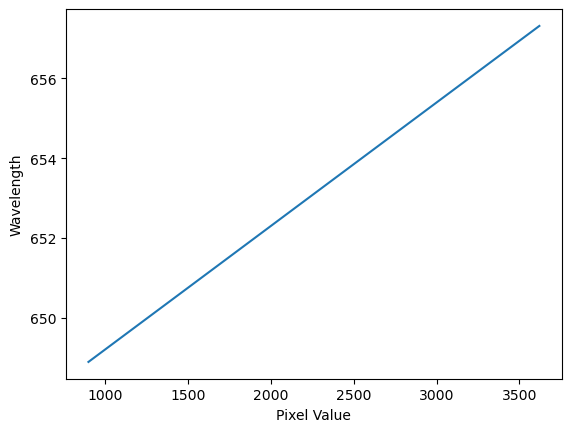

<Figure size 640x480 with 0 Axes>

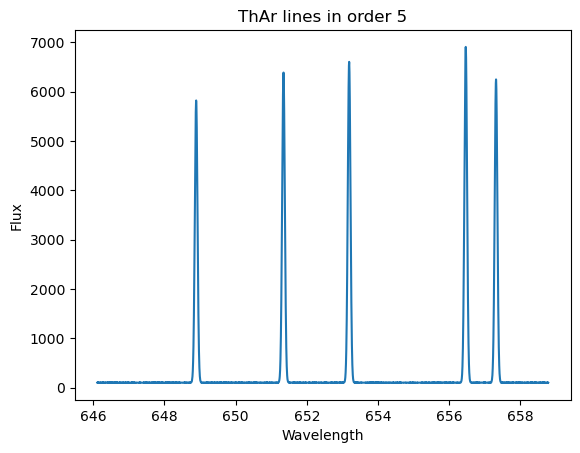

<Figure size 640x480 with 0 Axes>

In [76]:
lambda_lines = np.array(lines)
plt.plot(thar_lines,sorted(lambda_lines[:,0]))
coeffs = np.polyfit(thar_lines,sorted(lambda_lines[:,0]),1)
plt.xlabel("Pixel Value")
plt.ylabel("Wavelength")
plt.show()
pixel_vec = np.arange(0,len(thar_order))
ys = np.polyval(coeffs, pixel_vec)
plt.plot(ys, thar_order)
plt.title("ThAr lines in order 5")
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.figure()

# Congratulations!

You have successfully wavelength calibrated your order! 

# Task 8: Quality Checks
Now we must check to see if the wavelength calibration is correct.

Follow these steps:
1. Plot the original data from synth_spec.txt on top of your wavelength-calibrated order and verify the two sets of data align. You may need to modify the scaling of the fluxes.
2. Find the centre of the hydrogen line using code from Lab 2. 
3. Plot a vertical line using plt.axvline at the centre of the hydrogen line, and another one at 656.28nm. What does this tell us about this spectrum?

<Figure size 640x480 with 0 Axes>

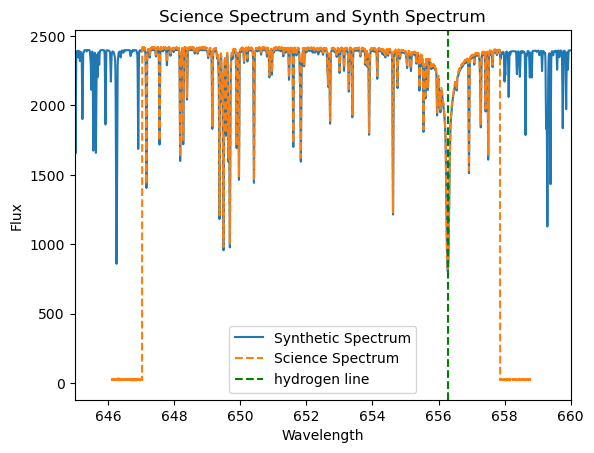

<Figure size 640x480 with 0 Axes>

In [102]:
synth_spec = np.loadtxt("//macdiarmid\ASTR211/2024_Lab_Files/Spec_Reduction_Lab/synth_spec.txt")
plt.plot(synth_spec[:,0],synth_spec[:,1] *2400, label="Synthetic Spectrum")

wavelengths = ys
plt.plot(wavelengths, order, label="Science Spectrum", linestyle='--')
plt.title("Science Spectrum and Synth Spectrum")
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.axvline(656.28, linestyle = "--", color="green", label="hydrogen line")
plt.xlim(645,660)
plt.legend()
plt.figure()

# Task 9: Wavelength calibrate all orders

Combine all your code to repeat this process for all 7 orders, and plot them together. How would you produce a full spectrum from this data?

7 7 7
7


C:\Users\lhy19\AppData\Local\Temp\ipykernel_5380\4181555227.py:28: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  wavelength_lines = np.array(thar_lines_orders_wavelength)


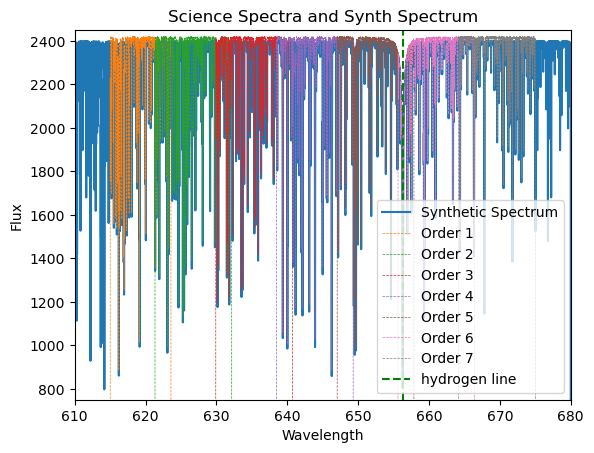

In [131]:
def get_raw_orders(min_reduced_raw, order_pixel_values):
    orders = []
    for value in order_pixel_values:
        orders.append(min_reduced_raw[value])
    return orders

def get_thar_orders(thar, order_pixel_values): #PIXELS!!!!
    orders = []
    for value in order_pixel_values:
        orders.append(thar[value])
    return orders

def get_lines_orders(filename, order_pixel_values): # WAVELENGTH
    n_orders = len(order_pixel_values)
    linelist = np.loadtxt(filename, skiprows=1)
    order_list = [sorted([line[0] for line in linelist if (line[2] == i or line[3] == i)]) for i in range(1,n_orders+1)]
    return order_list

def find_thar_lines(thar_orders): #### PIXELS!!!!!!
    thar_lines_orders = []
    for thar_order in thar_orders:
        thar_lines, info = sp.signal.find_peaks(thar_order, height = 2000)
        thar_lines_orders.append(thar_lines)
    return thar_lines_orders

def fit_thar_orders(thar_lines_orders_px, thar_lines_orders_wavelength): 
    #FIT order by order thar lines in px from my data to known wavelengths
    wavelength_lines = np.array(thar_lines_orders_wavelength)
    pixel_lines = thar_lines_orders_px

    fit_wavelengths_orders = []
    for pixels, wavelengths in zip(pixel_lines, wavelength_lines):
        coeffs = np.polyfit(pixels,wavelengths,1)
        fit_wavelengths = np.polyval(coeffs, pixel_vec)
        fit_wavelengths_orders.append(fit_wavelengths)
    return fit_wavelengths_orders

def plot_orders(fit_wavelengths_orders, raw_orders):
    for i in range(len(fit_wavelengths_orders)):
        xs = fit_wavelengths_orders[i]
        ys = raw_orders[i]
        plt.plot(xs,ys, label=f"Order {i+1}",linestyle="--",linewidth=0.5)


filename = "//macdiarmid\ASTR211/2024_Lab_Files/Spec_Reduction_Lab/ThAr_linelist.txt"
raw_orders = get_raw_orders(min_reduced_raw, order_pixel_values)
thar_orders = get_thar_orders(thar, order_pixel_values)
thar_orders_wavelengths = get_lines_orders(filename, order_pixel_values)
print(len(raw_orders), len(thar_orders), len(thar_orders_wavelengths))

thar_lines_orders_px = find_thar_lines(thar_orders)
thar_lines_orders_wavelength = thar_orders_wavelengths
print(len(thar_lines_orders_px))

fit_wavelengths = fit_thar_orders(thar_lines_orders_px,thar_lines_orders_wavelength)
plt.plot(synth_spec[:,0],synth_spec[:,1] *2400, label="Synthetic Spectrum")
plot_orders(fit_wavelengths, raw_orders)
plt.xlim(610,680)
plt.axvline(656.28, linestyle = "--", color="green", label="hydrogen line")
plt.title("Science Spectra and Synth Spectrum")
plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.ylim(750,2450)
plt.legend()